In [2]:
import os
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 6


def load_full_image(path, label, image_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, image_size)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([image_size[0], image_size[1], 1])

    return img, label

def load_bounding_box_only(path, label, image_size):

    # Read image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)

    H = tf.cast(tf.shape(img)[0], tf.float32)
    W = tf.cast(tf.shape(img)[1], tf.float32)

    # Locate corresponding label
    label_path = tf.strings.regex_replace(path, "/images/", "/labels/")
    label_path = tf.strings.regex_replace(label_path, r"\.(jpg|jpeg|png)$", ".txt")

    txt = tf.io.read_file(label_path)
    values = tf.strings.to_number(tf.strings.split(txt), tf.float32)

    x_center = values[1]
    y_center = values[2]
    width = values[3]
    height = values[4]

    # 10% margin
    margin = 1.10
    width *= margin
    height *= margin

    x1 = tf.cast((x_center - width / 2) * W, tf.int32)
    y1 = tf.cast((y_center - height / 2) * H, tf.int32)
    x2 = tf.cast((x_center + width / 2) * W, tf.int32)
    y2 = tf.cast((y_center + height / 2) * H, tf.int32)

    x1 = tf.maximum(x1, 0)
    y1 = tf.maximum(y1, 0)
    x2 = tf.minimum(x2, tf.cast(W, tf.int32))
    y2 = tf.minimum(y2, tf.cast(H, tf.int32))

    crop = img[y1:y2, x1:x2]

    # Pad to square (same behavior as OpenCV)
    side = tf.maximum(
        tf.shape(crop)[0],
        tf.shape(crop)[1]
    )
    
    crop = tf.image.resize_with_pad(
        crop,
        side,
        side
    )

    crop = tf.image.resize(crop, image_size)

    crop = tf.cast(crop, tf.float32) / 255.0

    crop.set_shape([image_size[0], image_size[1], 1])

    return crop, label

def create_dataset(
    image_dir,
    label_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True,
    load_func=load_full_image
):

    image_extensions = (".jpg", ".jpeg", ".png")

    image_paths = []
    labels = []

    for filename in os.listdir(image_dir):

        if not filename.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(image_dir, filename)

        label_path = os.path.join(
            label_dir,
            os.path.splitext(filename)[0] + ".txt"
        )

        if not os.path.exists(label_path):
            continue

        with open(label_path) as f:
            line = f.readline().strip()

        if line == "":
            continue

        class_id = int(line.split()[0])

        image_paths.append(image_path)
        labels.append(class_id)

    print(f"Loaded {len(image_paths)} file names.")

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        lambda path, label: load_func(path, label, image_size),
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(len(image_paths))

    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [3]:
from itertools import product
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    GlobalAveragePooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

def create_model(img_dim, conv_layers, first_num_tensors, first_kernel_dim, first_pooling_dim, flattening_api, 
                 dense_layers, first_num_neurons, last_dropout_prob):

    layers = [
        Input(shape=(img_dim[0], img_dim[1], 1))
    ]

    kernel_dim = first_kernel_dim
    pooling_dim = first_pooling_dim
    num_tensors = first_num_tensors
    for _ in range(conv_layers):
        layers.extend([
            Conv2D(num_tensors, kernel_dim, activation="relu"),
            MaxPooling2D(pooling_dim)
        ])
        kernel_dim = (3,3)
        pooling_dim = (2,2)
        num_tensors *= 2

    layers.extend([flattening_api()])

    dropout_prob = 0.0
    num_neurons = first_num_neurons
    for dense_layer in range(dense_layers):
        if dense_layer == dense_layers - 1:
            dropout_prob = last_dropout_prob
        layers.extend([
            Dense(num_neurons, activation="relu"),
            Dropout(dropout_prob),
        ])
        num_neurons //= 2

    layers.extend([Dense(NUM_CLASSES, activation="softmax")])
    
    model = Sequential(layers)
    return model

In [48]:
def find_best_model(img_dims, conv_layers_list, first_num_tensors_list, first_kernel_dims, first_pooling_dims, flattening_apis,
                   dense_layers_list, first_num_neurons_list, last_dropout_probs, batch_size, epochs, load_func=load_full_image):
    best_acc = 0.0
    best_epoch = -1
    best_params = {}
    for img_dim in img_dims:
        train_dataset = create_dataset(
            "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/train",
            "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/train",
            image_size=img_dim,
            batch_size=batch_size,
            shuffle=True,
            load_func=load_func
        )
    
        val_dataset = create_dataset(
            "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/val",
            "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/val",
            image_size=img_dim,
            batch_size=batch_size,
            shuffle=False,
            load_func=load_func
        )
    
        for (
            conv_layers,
            first_num_tensors,
            first_kernel_dim,
            first_pooling_dim,
            flattening_api,
            dense_layers,
            first_num_neurons,
            last_dropout_prob
        ) in product(
            conv_layers_list,
            first_num_tensors_list,
            first_kernel_dims,
            first_pooling_dims,
            flattening_apis,
            dense_layers_list,
            first_num_neurons_list,
            last_dropout_probs,
        ):
        
            model = create_model(
                img_dim,
                conv_layers,
                first_num_tensors,
                first_kernel_dim,
                first_pooling_dim,
                flattening_api,
                dense_layers,
                first_num_neurons,
                last_dropout_prob
            )
    
            model.compile(
                optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )
    
            history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                verbose=0
            )
    
            current_best_epoch = np.argmax(history.history["val_accuracy"]) + 1
            current_best_acc = history.history["val_accuracy"][current_best_epoch - 1]
    
            if current_best_acc > best_acc:
                best_epoch = current_best_epoch
                best_acc = current_best_acc
                best_params = {
                    "img_dim": img_dim,
                    "conv_layers": conv_layers,
                    "first_num_tensors": first_num_tensors,
                    "kernel": first_kernel_dim,
                    "pooling": first_pooling_dim,
                    "flatten": flattening_api,
                    "dense_layers": dense_layers,
                    "neurons": first_num_neurons,
                    "last_dropout": last_dropout_prob,
                    "best_epoch": best_epoch
                }
                print(best_params)
                print(f'val_acc = {best_acc} in epoch: {best_epoch}')
    return best_params, best_epoch, best_acc

In [14]:
img_dims = [(128,128), (256,256)]
conv_layers_list = [2, 3]
first_num_tensors_list = [32]
first_kernel_dims = [(3,3)]
first_pooling_dims = [(2,2)]
flattening_apis = [GlobalAveragePooling2D]
dense_layers_list = [0, 1, 2]
first_num_neurons_list = [128]
last_dropout_probs = [0.5]
batch_size = 32
epochs = 30

params, epoch, acc = find_best_model(img_dims, conv_layers_list, first_num_tensors_list, first_kernel_dims, first_pooling_dims, 
                                     flattening_apis, dense_layers_list, first_num_neurons_list, last_dropout_probs, batch_size, epochs)

Loaded 12267 file names.
Loaded 2629 file names.
{'img_dim': (128, 128), 'conv_layers': 2, 'first_num_tensors': 32, 'kernel': (3, 3), 'pooling': (2, 2), 'flatten': <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>, 'dense_layers': 0, 'neurons': 128, 'last_dropout': 0.5, 'best_epoch': np.int64(25)}
val_acc = 0.2179878056049347 in epoch: 25
{'img_dim': (128, 128), 'conv_layers': 3, 'first_num_tensors': 32, 'kernel': (3, 3), 'pooling': (2, 2), 'flatten': <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>, 'dense_layers': 0, 'neurons': 128, 'last_dropout': 0.5, 'best_epoch': np.int64(30)}
val_acc = 0.2606707215309143 in epoch: 30
Loaded 12267 file names.
Loaded 2629 file names.


In [22]:
params

{'img_dim': (128, 128),
 'conv_layers': 3,
 'first_num_tensors': 32,
 'kernel': (3, 3),
 'pooling': (2, 2),
 'flatten': keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D,
 'dense_layers': 0,
 'neurons': 128,
 'last_dropout': 0.5,
 'best_epoch': np.int64(30)}

In [5]:
img_dim = (128, 128)
conv_layers = 3
first_num_tensors = 32
first_kernel_dim = (3,3)
first_pooling_dim = (2,2)
flattening_api = GlobalAveragePooling2D
dense_layers = 0
first_num_neurons = 128
last_dropout_prob = 0.5
batch_size = 32

train_dataset = create_dataset(
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/train",
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/train",
    image_size=img_dim,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = create_dataset(
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/val",
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/val",
    image_size=img_dim,
    batch_size=batch_size,
    shuffle=False
)

model = create_model(
    img_dim,
    conv_layers,
    first_num_tensors,
    first_kernel_dim,
    first_pooling_dim,
    flattening_api,
    dense_layers,
    first_num_neurons,
    last_dropout_prob
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Loaded 12267 file names.


I0000 00:00:1783237254.305179      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Loaded 2629 file names.


In [6]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint]
)

Epoch 1/100
 18/383 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2282 - loss: 1.7736  

I0000 00:00:1783237309.704918     301 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


383/383 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.1960 - loss: 1.7539 - val_accuracy: 0.1997 - val_loss: 1.7508
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1944 - loss: 1.7513 - val_accuracy: 0.1993 - val_loss: 1.7497
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2017 - loss: 1.7502 - val_accuracy: 0.1993 - val_loss: 1.7501
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2019 - loss: 1.7500 - val_accuracy: 0.1993 - val_loss: 1.7500
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2013 - loss: 1.7503 - val_accuracy: 0.2035 - val_loss: 1.7504
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1967 - loss: 1.7501 - val_accuracy: 0.1993 - val_loss: 1.7495
Epoch 7/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1970 - loss: 1.7503 - val_accuracy: 0.1997 - val_loss: 1.7497
Epoch 8/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1992 - loss: 1.7497 - val_

In [7]:
# nalazimo model sa najboljim acc na validacionom skupu

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_acc = history.history["val_accuracy"][best_epoch - 1]

best_model_full = tf.keras.models.load_model("best_model.keras")
model = best_model_full

print(f"best accuracy: {best_acc} in epoch: {best_epoch}")

0.37614330649375916

In [ ]:
# save the model

best_model_full_pic.save("/kaggle/working/best_model_full.keras")

In [9]:
test_dataset = create_dataset(
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/test",
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/test",
    image_size=img_dim,
    batch_size=batch_size,
    shuffle=False
)

Loaded 2631 file names.


In [10]:
test_loss, test_acc = model.evaluate(test_dataset)

print("Test accuracy:", test_acc)

82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.3864 - loss: 1.9406
Test accuracy: 0.3864329159259796


In [49]:
img_dims = [(64,64), (128,128), (256,256)]
conv_layers_list = [3, 2]
first_num_tensors_list = [32]
first_kernel_dims = [(3,3)]
first_pooling_dims = [(2,2)]
flattening_apis = [GlobalAveragePooling2D]
dense_layers_list = [1, 0]
first_num_neurons_list = [128]
last_dropout_probs = [0.4]
batch_size = 32
epochs = 40

params, epoch, acc = find_best_model(img_dims, conv_layers_list, first_num_tensors_list, first_kernel_dims, first_pooling_dims, 
                                     flattening_apis, dense_layers_list, first_num_neurons_list, last_dropout_probs, batch_size, epochs, 
                                     load_bounding_box_only)

Loaded 12267 file names.
Loaded 2629 file names.
{'img_dim': (64, 64), 'conv_layers': 3, 'first_num_tensors': 32, 'kernel': (3, 3), 'pooling': (2, 2), 'flatten': <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>, 'dense_layers': 1, 'neurons': 128, 'last_dropout': 0.4, 'best_epoch': np.int64(33)}
val_acc = 0.8567073345184326 in epoch: 33
Loaded 12267 file names.
Loaded 2629 file names.
Loaded 12267 file names.
Loaded 2629 file names.


In [50]:
acc

0.8567073345184326

In [51]:
img_dim = (64,64)
conv_layers = 3
first_num_tensors = 32
first_kernel_dim = (3,3)
first_pooling_dim = (2,2)
flattening_api = GlobalAveragePooling2D
dense_layers = 1
first_num_neurons = 128
last_dropout_prob = 0.4
batch_size = 32

train_dataset = create_dataset(
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/train",
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/train",
    image_size=img_dim,
    batch_size=batch_size,
    shuffle=True,
    load_func=load_bounding_box_only
)

val_dataset = create_dataset(
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/val",
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/val",
    image_size=img_dim,
    batch_size=batch_size,
    shuffle=False,
    load_func=load_bounding_box_only
)

model = create_model(
    img_dim,
    conv_layers,
    first_num_tensors,
    first_kernel_dim,
    first_pooling_dim,
    flattening_api,
    dense_layers,
    first_num_neurons,
    last_dropout_prob
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Loaded 12267 file names.
Loaded 2629 file names.


In [52]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint]
)

Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.3172 - loss: 1.5626 - val_accuracy: 0.4158 - val_loss: 1.4347
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3989 - loss: 1.4291 - val_accuracy: 0.4527 - val_loss: 1.3411
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4736 - loss: 1.3002 - val_accuracy: 0.5023 - val_loss: 1.2331
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5166 - loss: 1.2087 - val_accuracy: 0.5716 - val_loss: 1.1147
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5559 - loss: 1.1201 - val_accuracy: 0.5911 - val_loss: 1.0582
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5860 - loss: 1.0504 - val_accuracy: 0.6380 - val_loss: 0.9698
Epoch 7/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6208 - loss: 0.9936 - val_accuracy: 0.6639 - val_loss: 0.9034
Epoch 8/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6621 - loss: 0.9011 -

In [53]:
# nalazimo model sa najboljim acc na validacionom skupu

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_acc = history.history["val_accuracy"][best_epoch - 1]

best_model_bbx = tf.keras.models.load_model("best_model.keras")
model = best_model_bbx

best_model_bbx.save("/kaggle/working/best_model_bbx.keras")

print(f"best accuracy: {best_acc} in epoch: {best_epoch}")

best accuracy: 0.8883383870124817 in epoch: 99


In [8]:
model = tf.keras.models.load_model("/kaggle/input/models/mrkkopr/bbx-cnn-model/other/default/1/best_model_bbx.keras")

In [12]:
img_dim = (64,64)
conv_layers = 3
first_num_tensors = 32
first_kernel_dim = (3,3)
first_pooling_dim = (2,2)
flattening_api = GlobalAveragePooling2D
dense_layers = 1
first_num_neurons = 128
last_dropout_prob = 0.4
batch_size = 32

test_dataset = create_dataset(
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/images/test",
    "/kaggle/input/datasets/markolazarevi/hagrid-fingers-yolo/fingers_yolo/labels/test",
    image_size=img_dim,
    batch_size=batch_size,
    shuffle=False,
    load_func=load_bounding_box_only
)

Loaded 2631 file names.


In [13]:
test_loss, test_acc = model.evaluate(test_dataset)

print("Test accuracy:", test_acc)

 3/82 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9010 - loss: 0.5802

I0000 00:00:1783266184.748856     124 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.8712 - loss: 0.5529
Test accuracy: 0.8711889982223511


In [14]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

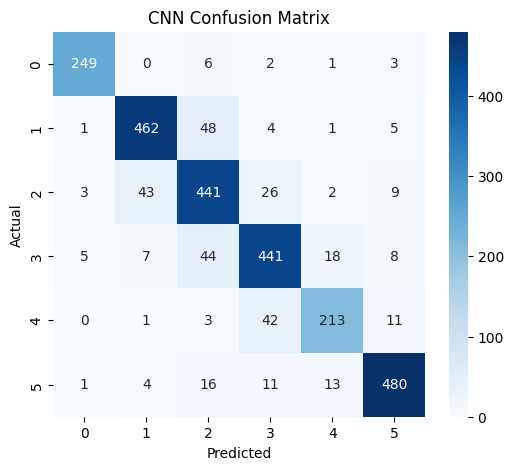

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [18]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

labels = np.unique(y_true)

precision = precision_score(y_true, y_pred, labels=labels, average=None)
recall = recall_score(y_true, y_pred, labels=labels, average=None)
f1 = f1_score(y_true, y_pred, labels=labels, average=None)

df = pd.DataFrame({
    "Class": labels,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1
})

display(
    df.style
      .hide(axis="index")
      .background_gradient(cmap="RdYlGn", subset=["Precision", "Recall", "F1 score"])
      .format("{:.3f}", subset=["Precision", "Recall", "F1 score"])
      .set_properties(**{
          "text-align": "center",
          "font-size": "12pt"
      })
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center"),
                                       ("font-size", "12pt"),
                                       ("font-weight", "bold")]}
      ])
)

Class,Precision,Recall,F1 score
0,0.961,0.954,0.958
1,0.894,0.887,0.890
2,0.790,0.842,0.815
3,0.838,0.843,0.841
4,0.859,0.789,0.822
5,0.930,0.914,0.922


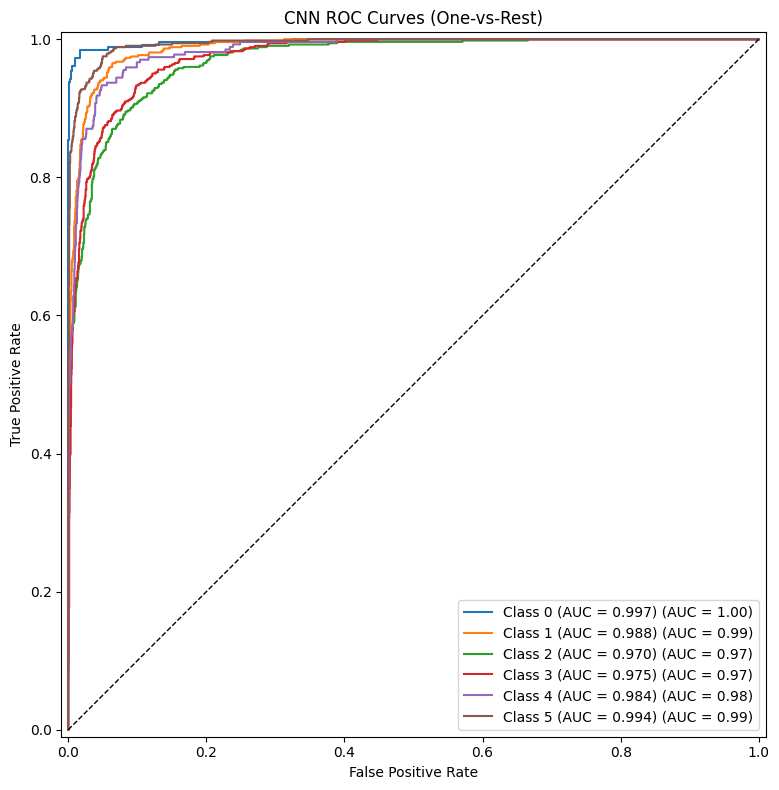

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# y_prob must already exist from prediction loop
y_score = np.array(y_prob)

labels = np.unique(y_true)

y_true_bin = label_binarize(y_true, classes=labels)

fig, ax = plt.subplots(figsize=(8, 8))

for i, label in enumerate(labels):
    auc = roc_auc_score(y_true_bin[:, i], y_score[:, i])

    RocCurveDisplay.from_predictions(
        y_true_bin[:, i],
        y_score[:, i],
        name=f"Class {label} (AUC = {auc:.3f})",
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("CNN ROC Curves (One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()